In [6]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import seaborn as sns
import numpy as np

In [7]:
event_2022 = pd.read_csv("event_data_2022.csv")
event_2023 = pd.read_csv("event_data_2023.csv")
tracking_2022 = pd.read_csv("tracking_2022_final.csv")
tracking_2023 = pd.read_csv("tracking_2023_final.csv")

In [ ]:
tracking_2022

In [3]:
event_2023.columns

Index(['id', 'player_id', 'team_id', 'minute', 'second', 'period', 'start_x',
       'start_y', 'end_x', 'end_y',
       ...
       'possession_penalty', 'match_time', 'approx_match_time', 'season',
       'match_id', 'competition', 'start_frame', 'frame', 'passer_x',
       'passer_y'],
      dtype='object', length=153)

In [4]:
event_2023 = event_2023.drop(['season'],axis=1)

In [8]:
event_2022['season'] = '2022'

# For 2023 tracking data
event_2023['season'] = '2023'

# Concatenate both
event_2022_2023 = pd.concat([event_2022, event_2023], ignore_index=True)

In [9]:
tracking_2022['season'] = '2022'

# For 2023 tracking data
tracking_2023['season'] = '2023'

# Concatenate both
tracking_2022_2023 = pd.concat([tracking_2022, tracking_2023], ignore_index=True)

In [7]:
event_2022_2023.shape

(74087, 176)

In [8]:
event_2022_2023

,id,player_id,team_id,opponent_team_id,minute,second,period,start_x,start_y,end_x,...,wing_play,pass_to_golden_zone,long_ball_from_back,keep_possession,central_through_ball,counterattack,counterpress,counterpress_success,passer_x,passer_y
0,1256506933,77272,6769,6766.0,2,25,1,54.60000,46.920000,81.900000,...,False,False,False,False,False,False,False,False,52.348120,47.416216
1,1256508233,546328,6766,6769.0,4,5,1,72.45000,46.240000,71.400000,...,False,False,False,False,False,False,False,False,73.702507,38.533333
2,1256507062,654790,6769,6766.0,6,52,1,61.95000,23.800000,72.450000,...,False,False,False,False,False,False,False,False,58.544841,23.115916
3,1256507101,654790,6769,6766.0,7,51,1,88.20000,63.240000,101.850000,...,False,False,False,False,False,False,False,False,83.827869,63.109309
4,1256507134,582334,6769,6766.0,8,58,1,72.45000,6.800000,77.700000,...,True,False,False,True,False,False,False,False,69.601736,3.236637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74082,1625749288,212662,6721,NaN,91,56,2,92.61000,16.979328,97.830926,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81.181916,32.295396
74083,1625749300,587166,6721,NaN,92,53,2,67.14225,2.829888,93.058686,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.054622,63.104807
74084,1625749310,676013,6721,NaN,94,9,2,105.00000,2.829888,105.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.081839,63.659574
74085,1625748978,581623,6754,NaN,95,22,2,76.40325,13.835008,105.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79.738894,34.940448


In [9]:
events_test = event_2022_2023[event_2022_2023["possession_xg"]!=0]

In [10]:
events_test["possession_xg"].describe()

count    18461.000000
mean         0.108571
std          0.120216
min          0.000100
25%          0.024800
50%          0.066100
75%          0.150000
max          0.857400
Name: possession_xg, dtype: float64

In [11]:
event_2022_2023.columns

Index(['id', 'player_id', 'team_id', 'opponent_team_id', 'minute', 'second',
       'period', 'start_x', 'start_y', 'end_x',
       ...
       'wing_play', 'pass_to_golden_zone', 'long_ball_from_back',
       'keep_possession', 'central_through_ball', 'counterattack',
       'counterpress', 'counterpress_success', 'passer_x', 'passer_y'],
      dtype='object', length=176)

In [10]:
def xG_target_cal(x):
    if x < 0.066100:
        return 0
    return 1

In [11]:
event_2022_2023["possession_xG_target"] = event_2022_2023["possession_xg"].apply(xG_target_cal)

In [12]:
tracking_2022_2023.columns

Index(['id', 'team_id', 'team', 'possession_team_id', 'x_adjusted',
       'y_adjusted', 'team_direction', 'player_name', 'player_id',
       'pitch_length', 'pitch_width', 'season'],
      dtype='object')

In [16]:
#tracking_2022_2023.to_csv("tracking_final_2022_2023.csv",index=False)

In [13]:
event_ids = set(event_2022_2023['id'])
tracking_ids = set(tracking_2022_2023['id'])

# Find mismatches
ids_in_event_not_in_tracking = event_ids - tracking_ids
ids_in_tracking_not_in_event = tracking_ids - event_ids

# Display results
print("IDs in event but not in tracking:", ids_in_event_not_in_tracking)
print("IDs in tracking but not in event:", ids_in_tracking_not_in_event)

IDs in event but not in tracking: set()
IDs in tracking but not in event: set()


In [18]:
event_2022_2023

,id,player_id,team_id,opponent_team_id,minute,second,period,start_x,start_y,end_x,...,pass_to_golden_zone,long_ball_from_back,keep_possession,central_through_ball,counterattack,counterpress,counterpress_success,passer_x,passer_y,possession_xG_target
0,1256506933,77272,6769,6766.0,2,25,1,54.60000,46.920000,81.900000,...,False,False,False,False,False,False,False,52.348120,47.416216,0
1,1256508233,546328,6766,6769.0,4,5,1,72.45000,46.240000,71.400000,...,False,False,False,False,False,False,False,73.702507,38.533333,0
2,1256507062,654790,6769,6766.0,6,52,1,61.95000,23.800000,72.450000,...,False,False,False,False,False,False,False,58.544841,23.115916,0
3,1256507101,654790,6769,6766.0,7,51,1,88.20000,63.240000,101.850000,...,False,False,False,False,False,False,False,83.827869,63.109309,0
4,1256507134,582334,6769,6766.0,8,58,1,72.45000,6.800000,77.700000,...,False,False,True,False,False,False,False,69.601736,3.236637,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74082,1625749288,212662,6721,NaN,91,56,2,92.61000,16.979328,97.830926,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81.181916,32.295396,0
74083,1625749300,587166,6721,NaN,92,53,2,67.14225,2.829888,93.058686,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.054622,63.104807,0
74084,1625749310,676013,6721,NaN,94,9,2,105.00000,2.829888,105.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.081839,63.659574,0
74085,1625748978,581623,6754,NaN,95,22,2,76.40325,13.835008,105.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79.738894,34.940448,0


In [19]:
tracking_2022_2023.shape

(1619708, 12)

In [14]:
tracking_2022_2023_final = pd.read_csv("tracking_final_2022_2023.csv")

In [15]:
tracking_2022_2023_final.columns

Index(['id', 'team_id', 'team', 'possession_team_id', 'x_adjusted',
       'y_adjusted', 'team_direction', 'player_name', 'player_id',
       'pitch_length', 'pitch_width', 'season', 'speed'],
      dtype='object')

In [16]:
tracking_2022_2023['speed'] = tracking_2022_2023_final['speed']

In [17]:
event_tracking_features_2022_2023 = event_2022_2023[["id","player_id","pass_recipient_id","match_id","start_x","start_y","team_id","passer_x","passer_y","end_x","end_y","possession_xG_target","possession_goal","possession_xg","season"]].reset_index(drop=True)

In [24]:
event_tracking_features_2022_2023

,id,player_id,pass_recipient_id,match_id,start_x,start_y,team_id,passer_x,passer_y,end_x,end_y,possession_xG_target,possession_goal,possession_xg,season
0,1256506933,77272,487935,5321419,54.60000,46.920000,6769,52.348120,47.416216,81.900000,63.920000,0,False,0.0000,2022
1,1256508233,546328,272752,5321419,72.45000,46.240000,6766,73.702507,38.533333,71.400000,19.040000,0,False,0.0000,2022
2,1256507062,654790,582334,5321419,61.95000,23.800000,6769,58.544841,23.115916,72.450000,2.040000,0,False,0.0000,2022
3,1256507101,654790,77272,5321419,88.20000,63.240000,6769,83.827869,63.109309,101.850000,61.200000,0,False,0.0000,2022
4,1256507134,582334,259306,5321419,72.45000,6.800000,6769,69.601736,3.236637,77.700000,12.920000,0,False,0.0000,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74082,1625749288,212662,509754,5420697,92.61000,16.979328,6721,81.181916,32.295396,97.830926,23.332090,0,False,0.0209,2023
74083,1625749300,587166,607268,5420697,67.14225,2.829888,6721,55.054622,63.104807,93.058686,5.508966,0,False,0.0000,2023
74084,1625749310,676013,587166,5420697,105.00000,2.829888,6721,102.081839,63.659574,105.000000,9.397648,0,False,0.0000,2023
74085,1625748978,581623,730438,5420697,76.40325,13.835008,6754,79.738894,34.940448,105.000000,3.240568,0,False,0.0000,2023


In [18]:
event_tracking_features_2022_2023.insert(4,"possession_team_id",tracking_2022_2023["possession_team_id"])
event_tracking_features_2022_2023.columns

Index(['id', 'player_id', 'pass_recipient_id', 'match_id',
       'possession_team_id', 'start_x', 'start_y', 'team_id', 'passer_x',
       'passer_y', 'end_x', 'end_y', 'possession_xG_target', 'possession_goal',
       'possession_xg', 'season'],
      dtype='object')

In [22]:
event_tracking_features_2022_2023

,id,player_id,pass_recipient_id,match_id,possession_team_id,start_x,start_y,team_id,passer_x,passer_y,end_x,end_y,possession_xG_target,possession_goal,possession_xg,season
0,1256506933,77272,487935,5321419,6769,54.60000,46.920000,6769,52.348120,47.416216,81.900000,63.920000,0,False,0.0000,2022
1,1256508233,546328,272752,5321419,6769,72.45000,46.240000,6766,73.702507,38.533333,71.400000,19.040000,0,False,0.0000,2022
2,1256507062,654790,582334,5321419,6769,61.95000,23.800000,6769,58.544841,23.115916,72.450000,2.040000,0,False,0.0000,2022
3,1256507101,654790,77272,5321419,6769,88.20000,63.240000,6769,83.827869,63.109309,101.850000,61.200000,0,False,0.0000,2022
4,1256507134,582334,259306,5321419,6769,72.45000,6.800000,6769,69.601736,3.236637,77.700000,12.920000,0,False,0.0000,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74082,1625749288,212662,509754,5420697,6769,92.61000,16.979328,6721,81.181916,32.295396,97.830926,23.332090,0,False,0.0209,2023
74083,1625749300,587166,607268,5420697,6769,67.14225,2.829888,6721,55.054622,63.104807,93.058686,5.508966,0,False,0.0000,2023
74084,1625749310,676013,587166,5420697,6769,105.00000,2.829888,6721,102.081839,63.659574,105.000000,9.397648,0,False,0.0000,2023
74085,1625748978,581623,730438,5420697,6769,76.40325,13.835008,6754,79.738894,34.940448,105.000000,3.240568,0,False,0.0000,2023


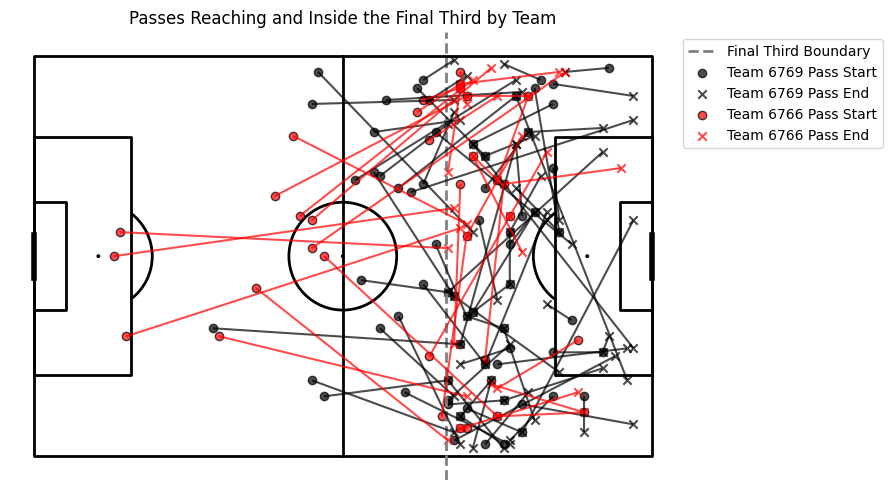

In [23]:
# Filter passes for a specific match
event_tracking_features_2022_2023["match_id"] = event_tracking_features_2022_2023["match_id"].astype(int)
data = event_tracking_features_2022_2023.loc[event_tracking_features_2022_2023["match_id"] == 5321419].head(100)

# Get unique team IDs
teams_to_consider = data['team_id'].unique()

# Filter passes that reach the final third
final_third_passes = data[(data['team_id'].isin(teams_to_consider))]

# Define pitch dimensions
pitch_width, pitch_height = 105, 68
final_third_x = pitch_width * 2 / 3  # Final third boundary

# Assign colors dynamically for each team
#colors = plt.cm.get_cmap('Paired', len(teams_to_consider))

team_colors = {
    teams_to_consider[0]: "black",  # Dark black for first team
    teams_to_consider[1]: "red"    # Blue for second team
}


# Create the pitch using mplsoccer
pitch = Pitch(pitch_type='custom', pitch_length=pitch_width, pitch_width=pitch_height, line_color='black')
fig, ax = pitch.draw(figsize=(10, 5))

# Mark the final third boundary
ax.axvline(x=final_third_x, color='gray', linestyle='--', linewidth=2, label='Final Third Boundary')

# Plot passes for each team
for team_id in teams_to_consider:
    team_passes = final_third_passes[final_third_passes['team_id'] == team_id]
    
    # Scatter start positions
    pitch.scatter(team_passes['start_x'], team_passes['start_y'], 
                  ax=ax, color=team_colors[team_id], label=f'Team {team_id} Pass Start', alpha=0.7, edgecolors='black')

    # Scatter end positions
    pitch.scatter(team_passes['end_x'], team_passes['end_y'], 
                  ax=ax, color=team_colors[team_id], marker='x', label=f'Team {team_id} Pass End', alpha=0.7)

    # Draw pass lines
    for _, row in team_passes.iterrows():
        pitch.lines(row['start_x'], row['start_y'], row['end_x'], row['end_y'], 
                    ax=ax, color=team_colors[team_id], alpha=0.7, linewidth=1.5)

# Configure plot
plt.title('Passes Reaching and Inside the Final Third by Team')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

# Show the plot
plt.show()


### Passer distance to goal

In [26]:
def passer_goal_distance(row):
    goal_center = np.array([105, 34])  # Center of the goal post
    start_location = np.array([row['passer_x'],row['passer_y']]) #pass start location

    distance_to_goal = np.linalg.norm(start_location - goal_center)
    return distance_to_goal

In [27]:
event_tracking_features_2022_2023['start_distance_to_goal'] = event_tracking_features_2022_2023.apply(passer_goal_distance,axis=1)

In [28]:
event_tracking_features_2022_2023

,id,player_id,pass_recipient_id,match_id,possession_team_id,start_x,start_y,team_id,passer_x,passer_y,end_x,end_y,possession_xG_target,possession_goal,possession_xg,season,start_distance_to_goal
0,1256506933,77272,487935,5321419,6769,54.60000,46.920000,6769,52.348120,47.416216,81.900000,63.920000,0,False,0.0000,2022,54.334293
1,1256508233,546328,272752,5321419,6769,72.45000,46.240000,6766,73.702507,38.533333,71.400000,19.040000,0,False,0.0000,2022,31.624107
2,1256507062,654790,582334,5321419,6769,61.95000,23.800000,6769,58.544841,23.115916,72.450000,2.040000,0,False,0.0000,2022,47.713154
3,1256507101,654790,77272,5321419,6769,88.20000,63.240000,6769,83.827869,63.109309,101.850000,61.200000,0,False,0.0000,2022,35.994597
4,1256507134,582334,259306,5321419,6769,72.45000,6.800000,6769,69.601736,3.236637,77.700000,12.920000,0,False,0.0000,2022,46.897992
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74082,1625749288,212662,509754,5420697,6769,92.61000,16.979328,6721,81.181916,32.295396,97.830926,23.332090,0,False,0.0209,2023,23.879004
74083,1625749300,587166,607268,5420697,6769,67.14225,2.829888,6721,55.054622,63.104807,93.058686,5.508966,0,False,0.0000,2023,57.806838
74084,1625749310,676013,587166,5420697,6769,105.00000,2.829888,6721,102.081839,63.659574,105.000000,9.397648,0,False,0.0000,2023,29.802785
74085,1625748978,581623,730438,5420697,6769,76.40325,13.835008,6754,79.738894,34.940448,105.000000,3.240568,0,False,0.0000,2023,25.278606


### Receiver distance to goal

In [29]:
def Pass_end_goal_distance(row):
    goal_center = np.array([105, 34])  # Center of the goal post
    end_location = np.array([row['end_x'],row['end_y']]) #pass end location

    distance_to_goal = np.linalg.norm(end_location - goal_center)
    return distance_to_goal

In [30]:
event_tracking_features_2022_2023['end_distance_to_goal'] = event_tracking_features_2022_2023.apply(Pass_end_goal_distance,axis=1)

### Pass length

In [31]:
def euclidean_distance(x1, y1, x2, y2):
    return np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

In [32]:
event_tracking_features_2022_2023['pass_length'] = event_tracking_features_2022_2023.apply(lambda row: euclidean_distance(row['passer_x'], row['passer_y'], 
                                                              row['end_x'], row['end_y']), axis=1)

### pass angle (angle between passer and pass end location)

In [33]:
def pass_angle(passer_x,passer_y,end_x,end_y):
    dist_start = end_x - passer_x 
    dist_end   = end_y - passer_y
    angle_pass = np.degrees(np.arctan2(dist_end,dist_start))
    angle_pass = (angle_pass + 360) % 360
    return angle_pass

In [34]:
event_tracking_features_2022_2023['pass_angle'] = event_tracking_features_2022_2023.apply(lambda row: pass_angle(row['passer_x'],row['passer_y'],row['end_x'],row['end_y']),axis=1)

### passer angle to the goal

In [35]:
def passer_angle_to_goal(row):
    goal_length = 7.32  # Length of the goal post from center
    ball_start_position = np.array([row['passer_x'], row['passer_y']]) #start location of the passer
    C = abs(ball_start_position[1] - 34)
    angle_passer = np.where(
        np.arctan(7.32 * ball_start_position[0] / (ball_start_position[0]**2 + C**2 - (goal_length/2)**2)) > 0,
        np.arctan(7.32 * ball_start_position[0] / (ball_start_position[0]**2 + C**2 - (goal_length/2)**2)),
        np.arctan(7.32 * ball_start_position[0] / (ball_start_position[0]**2 + C**2 - (goal_length/2)**2)) + np.pi
        )
    
    angle_passer = np.degrees(angle_passer) #converting to degrees
    
   
    return angle_passer

In [36]:
event_tracking_features_2022_2023['start_angle_to_goal'] = event_tracking_features_2022_2023.apply(passer_angle_to_goal,axis=1)

### Receiver angle to goal

In [37]:
def pass_end_angle_to_goal(row):
    goal_length = 7.32  # Length of the goal post from center
    ball_end_position = np.array([row['end_x'], row['end_y']]) #end location of the receiver
    C = abs(ball_end_position[1] - 34)
    angle_pass_end = np.where(
        np.arctan(7.32 * ball_end_position[0] / (ball_end_position[0]**2 + C**2 - (goal_length/2)**2)) > 0,
        np.arctan(7.32 * ball_end_position[0] / (ball_end_position[0]**2 + C**2 - (goal_length/2)**2)),
        np.arctan(7.32 * ball_end_position[0] / (ball_end_position[0]**2 + C**2 - (goal_length/2)**2)) + np.pi
        )
    
    angle_pass_end = np.degrees(angle_pass_end) #converting to degrees
    
   
    return angle_pass_end

In [38]:
event_tracking_features_2022_2023['end_angle_to_goal'] = event_tracking_features_2022_2023.apply(pass_end_angle_to_goal,axis=1)

### Passer sideline distance and Receiver sideline distance

In [39]:
def distances_to_sidelines(row):
    pitch_width=68
    passer_sideline = min(row['passer_y'],(pitch_width - row['passer_y'])) #min value of distance of sideline frome start location
    receiver_sideline = min(row['end_y'],(pitch_width - row['end_y'])) #min values of distance of sideline from end location
    return passer_sideline,receiver_sideline

In [40]:
event_tracking_features_2022_2023[['start_distance_to_sideline', 'end_distance_to_sideline',]] = event_tracking_features_2022_2023.apply(lambda row:pd.Series(distances_to_sidelines(row)),axis=1)

### Pass classification

In [41]:
event_tracking_features_2022_2023['forward pass'] = ((event_tracking_features_2022_2023['pass_angle'] >= 0) & (event_tracking_features_2022_2023['pass_angle'] <= 70)) | ((event_tracking_features_2022_2023['pass_angle'] >= 290) & (event_tracking_features_2022_2023['pass_angle'] <= 360))
event_tracking_features_2022_2023['backward pass'] = (event_tracking_features_2022_2023['pass_angle'] >= 110) & (event_tracking_features_2022_2023['pass_angle'] <= 250)
event_tracking_features_2022_2023['lateral pass'] = ((event_tracking_features_2022_2023['pass_angle'] > 70) & (event_tracking_features_2022_2023['pass_angle'] <110)) | ((event_tracking_features_2022_2023['pass_angle'] > 250) & (event_tracking_features_2022_2023['pass_angle'] <290))


### teammates behind the passer for different pass types

In [42]:
def teammates_behind_passer(row, framess):
    passer_x = row['passer_x']
    frame_id = row['id']
    team_id = row['team_id']


    # Filter frames for the current frame and team
    similar_frames = framess[(framess['id'] == frame_id) & (framess['team_id'] == team_id)]


    # Initialize the count
    teammates_behind = 0


    # Check pass type first
    if row['forward pass']:
        # forward passes : count teammates with x_adjusted > passer_x (passer start location)
        teammates_behind = similar_frames[similar_frames['x_adjusted'] < passer_x]
        teammates_behind = len(teammates_behind)

    elif row['backward pass']:
        teammates_behind = similar_frames[similar_frames['x_adjusted'] > passer_x]
        teammates_behind = len(teammates_behind)

    elif row['lateral pass']:
        # For lateral down pass: count teammates with y_adjusted < ball_y (below the ball)
        teammates_behind = similar_frames[similar_frames['x_adjusted'] < passer_x]
        teammates_behind = len(teammates_behind)


    row["teammates_behind"] = teammates_behind
    return row

In [43]:
event_tracking_features_2022_2023 = event_tracking_features_2022_2023.apply(lambda row : teammates_behind_passer(row,tracking_2022_2023),axis=1)


In [44]:
event_tracking_features_2022_2023.columns

Index(['id', 'player_id', 'pass_recipient_id', 'match_id',
       'possession_team_id', 'start_x', 'start_y', 'team_id', 'passer_x',
       'passer_y', 'end_x', 'end_y', 'possession_xG_target', 'possession_goal',
       'possession_xg', 'season', 'start_distance_to_goal',
       'end_distance_to_goal', 'pass_length', 'pass_angle',
       'start_angle_to_goal', 'end_angle_to_goal',
       'start_distance_to_sideline', 'end_distance_to_sideline',
       'forward pass', 'backward pass', 'lateral pass', 'teammates_behind'],
      dtype='object')

### teammates beyond passer

In [45]:
def teammates_beyond_passer(row, framess):
    passer_x = row['passer_x']
    frame_id = row['id']
    team_id = row['team_id']


    # Filter frames for the current frame and team
    similar_frames = framess[(framess['id'] == frame_id) & (framess['team_id'] == team_id)]


    # Initialize the count
    teammates_beyond = 0


    # Check pass type first
    if row['forward pass']:
        # forward passes : count teammates with x_adjusted > passer_x (passer start location)
        teammates_beyond = similar_frames[similar_frames['x_adjusted'] > passer_x]
        teammates_beyond = len(teammates_beyond)

    elif row['backward pass']:
        # forward passes : count teammates with x_adjusted  passer_x (passer start location)
        teammates_beyond = similar_frames[similar_frames['x_adjusted'] < passer_x]
        teammates_beyond = len(teammates_beyond)

    elif row['lateral pass']:
        # For lateral down pass: count teammates with y_adjusted < ball_y (below the ball)
        teammates_beyond = similar_frames[similar_frames['x_adjusted'] > passer_x]
        teammates_beyond = len(teammates_beyond)


    row["teammates_beyond"] = teammates_beyond
    return row

In [46]:
event_tracking_features_2022_2023 = event_tracking_features_2022_2023.apply(lambda row : teammates_beyond_passer(row,tracking_2022_2023),axis=1)


### opponents behind passer

In [47]:
def opponents_beyond_passer(row, framess):
    passer_x = row['passer_x']
    frame_id = row['id']

    opponents_beyond = 0
    # Check pass type first
    if row['forward pass']:
        # forward passes : count teammates with x_adjusted > passer_x (passer start location)
        opponents_beyond = framess[(framess['id'] == frame_id) & ((105-framess['x_adjusted']) > passer_x) & (framess['team_id'] != framess['possession_team_id'])]['x_adjusted'].count()

    elif row['backward pass']:
        # forward passes : count teammates with x_adjusted > passer_x (passer start location)
        opponents_beyond = framess[(framess['id'] == frame_id) & ((105-framess['x_adjusted']) < passer_x) & (framess['team_id'] != framess['possession_team_id'])]['x_adjusted'].count()

    elif row['lateral pass']:
        # For lateral down pass: count teammates with y_adjusted < ball_y (below the ball)
        opponents_beyond = framess[(framess['id'] == frame_id) & ((105-framess['x_adjusted']) > passer_x) & (framess['team_id'] != framess['possession_team_id'])]['x_adjusted'].count()

    row["opponents_beyond"] = opponents_beyond
    return row

In [48]:
event_tracking_features_2022_2023 = event_tracking_features_2022_2023.apply(lambda row : opponents_beyond_passer(row,tracking_2022_2023),axis=1)


### opponents behind passer

In [49]:
def opponents_behind_passer(row, framess):
    passer_x = row['passer_x']
    frame_id = row['id']

    opponents_behind = 0
    # Check pass type first
    if row['forward pass']:
        # forward passes : count teammates with x_adjusted > passer_x (passer start location)
        opponents_behind = framess[(framess['id'] == frame_id) & ((105-framess['x_adjusted']) < passer_x) & (framess['team_id'] != framess['possession_team_id'])]['x_adjusted'].count()

    elif row['backward pass']:
        # forward passes : count teammates with x_adjusted > passer_x (passer start location)
        opponents_behind = framess[(framess['id'] == frame_id) & ((105-framess['x_adjusted']) > passer_x) & (framess['team_id'] != framess['possession_team_id'])]['x_adjusted'].count()

    elif row['lateral pass']:
        # For lateral down pass: count teammates with y_adjusted < ball_y (below the ball)
        opponents_behind = framess[(framess['id'] == frame_id) & ((105-framess['x_adjusted']) < passer_x) & (framess['team_id'] != framess['possession_team_id'])]['x_adjusted'].count()

    row["opponents_behind"] = opponents_behind
    return row

In [50]:
event_tracking_features_2022_2023 = event_tracking_features_2022_2023.apply(lambda row : opponents_behind_passer(row,tracking_2022_2023),axis=1)


### Opponents inbetween

In [51]:
import numpy as np
import pandas as pd

def opponents_between(row, framess):
    passer_x = row['passer_x']
    end_x = row['end_x']
    passer_y = row['passer_y']
    end_y = row["end_y"]
    frame_id = row['id']
    x_adjusted = 105 - framess['x_adjusted']
    y_adjusted = 68 - framess['y_adjusted']

    # Initialize to 0
    opponents_between_compare = 0  

    # Forward Pass: Count opponents between passer_x and end_x
    if row.get('forward pass', False):
        min_x = min(passer_x, end_x)
        max_x = max(passer_x, end_x)

        opponents_between_compare = framess[
            (framess['id'] == frame_id) &
            (x_adjusted > min_x) &  # Ensure opponents are between passer_x and end_x
            (x_adjusted < max_x) &
            (framess['team_id'] != framess['possession_team_id'])]['x_adjusted'].count()

    # Backward Pass: Count opponents if end_x < passer_x
    elif row.get('backward pass', False):
        min_x = min(passer_x, end_x)
        max_x = max(passer_x, end_x)

        opponents_between_compare = framess[
            (framess['id'] == frame_id) &
            (x_adjusted > min_x) &  
            (x_adjusted < max_x) &
            (framess['team_id'] != framess['possession_team_id'])]['x_adjusted'].count()
        
    # Lateral Pass: Count opponents between passer_y and end_y
    elif row.get('lateral pass', False):
        min_y = min(passer_y, end_y)
        max_y = max(passer_y, end_y)

        opponents_between_compare = framess[
            (framess['id'] == frame_id) &
            (y_adjusted > min_y) &  
            (y_adjusted < max_y) &
            (framess['team_id'] != framess['possession_team_id'])]['y_adjusted'].count()

    row["opponents_between"] = opponents_between_compare
    return row


In [52]:
event_tracking_features_2022_2023 = event_tracking_features_2022_2023.apply(lambda row : opponents_between(row,tracking_2022_2023),axis=1)

### bypass opponents

In [53]:
def count_bypassed_opponents_new(row, frames, distance_threshold=5):  
    frame_id = row['id']
    passer_x = row['passer_x']
    passer_y = row['passer_y']
    end_x = row['end_x']
    end_y = row['end_y']

    # Compute the pass vector
    pass_vector_x = end_x - passer_x
    pass_vector_y = end_y - passer_y
    pass_length_sq = pass_vector_x**2 + pass_vector_y**2

    if pass_length_sq < 1e-6:  
        return 0  

    # Filter opponent players
    opponents = frames[(frames['id'] == frame_id) & 
                       (frames['team_id'] != frames['possession_team_id'])]

    if opponents.empty:
        return 0  

    # Flip opponent coordinates (Ensuring correct field orientation)
    opp_x = 105 - opponents['x_adjusted']
    opp_y = 68 - opponents['y_adjusted']

    # Compute perpendicular distances (Pandas-based)
    num = ((end_y - passer_y) * opp_x - (end_x - passer_x) * opp_y + 
           (end_x * passer_y - end_y * passer_x)).abs()
    den = ((end_y - passer_y)**2 + (end_x - passer_x)**2) ** 0.5
    den = float('inf') if den == 0 else den  # Replace 0 with infinity
    distance = num / den  

    # Projection of the opponent onto the pass vector (Pandas-based)
    t_proj = ((opp_x - passer_x) * pass_vector_x + (opp_y - passer_y) * pass_vector_y) / pass_length_sq

    # Filter opponents within the pass segment and threshold
    bypassed = (t_proj.between(0, 1)) & (distance <= distance_threshold)

    return bypassed.sum()  # Ensure integer count


In [54]:
event_tracking_features_2022_2023["packing"] = event_tracking_features_2022_2023.apply(lambda row: count_bypassed_opponents_new(row, tracking_2022_2023, distance_threshold=5), axis=1)

### Passer pressure

In [55]:
def compute_opponent_pressure_passer(row, frames, threshold=6):

    
    # Extract  position from the events row.
    pass_x, pass_y = row['passer_x'], row['passer_y']
    frame_id = row['id']  # Unique frame identifier.
    
    # Use opponent_team_id from the events row
    #opponent_team_id = row['opponent_team_id']
    
    # Check if the frame exists in the tracking data.
    if frame_id not in frames['id'].values:
        return 0.0, 0, "No Data"
    
    # Filter the tracking data for the given frame.
    relevant_frames = frames[frames['id'] == frame_id]
    if relevant_frames.empty:
        return 0.0, 0, "No Data"
    
    #possession_team_id = row['possession_team_id']

    
    # teammates and opponents.
    
    teammates = relevant_frames[relevant_frames['team_id'] == relevant_frames['possession_team_id']].copy()
    opponents = relevant_frames[relevant_frames['team_id'] != relevant_frames['possession_team_id']].copy()
    
    #  distances for teammates with normal coordinates.
    teammates['distance'] = np.sqrt(
        (teammates['x_adjusted'] - pass_x) ** 2 + (teammates['y_adjusted'] - pass_y) ** 2
    )
    
    #  distances for opponents using a flipped coordinate system.
    
    opponents['distance'] = np.sqrt(
        ((105 - opponents['x_adjusted']) - pass_x) ** 2 + ((68 - opponents['y_adjusted']) - pass_y) ** 2
    )
    
    # counts pressure
    total_pressure = 0.0
    count_opponents = 0
    # Loop over  opponents 
    for distance in opponents['distance']:
        if distance < threshold:
            count_opponents += 1
            # Linear decay: weight is 1 when distance is 0, 0 when distance equals threshold.
            weight = 1 - (distance / threshold)
            total_pressure += weight

    # Classify pressure level based on the count.
    if count_opponents <= 2:
        pressure_level = "Low Pressure"
    elif count_opponents <= 4:
        pressure_level = "Middle Pressure"
    else:
        pressure_level = "High Pressure"
        
    return total_pressure, count_opponents, pressure_level


In [56]:
event_tracking_features_2022_2023[['pressure_on_passer', 'opponents_nearby', 'pressure level passer']] = event_tracking_features_2022_2023.apply(
    lambda row: pd.Series(compute_opponent_pressure_passer(row,tracking_2022_2023, threshold=6)),
    axis=1
)

### average speed of teammates and opponents

In [57]:
def cal_average_speed_opponents(row,framesdf):
    event_frame_id = row["id"]
    team_id = row['team_id']

    similar_frames = framesdf[framesdf["id"] == event_frame_id]
    team_same = similar_frames[similar_frames["team_id"] == team_id]
    opponent_team = similar_frames[similar_frames["team_id"] != similar_frames["possession_team_id"]]

    average_speed_team = team_same["speed"].mean() if not team_same.empty else 0.0
    average_speed_opponent = opponent_team['speed'].mean() if not opponent_team.empty else 0.0

    return average_speed_team,average_speed_opponent

In [58]:
event_tracking_features_2022_2023[["average_speed_of_teammates","average_speed_of_opponents"]] = event_tracking_features_2022_2023.apply(lambda row:pd.Series(cal_average_speed_opponents(row,tracking_2022_2023)),axis=1)


### teammates near the passer

In [59]:
def count_teammates_near_passer(row, framess, threshold=6):
    passer_x, passer_y = row['passer_x'], row['passer_y']  # Passer’s position
    frame_id = row['id']
    team_id = row['team_id']  # Passer's team ID
    # Extract teammates (excluding the passer)
    relevant_teammates = framess[
        (framess['id'] == frame_id) &
        (framess['team_id'] == team_id)
    ]
    if relevant_teammates.empty:
        return np.nan  # No teammates found in the frame
    # Compute distances from passer to all teammates
    relevant_teammates['distances'] = np.sqrt(
        (relevant_teammates['x_adjusted'] - passer_x) ** 2 +
        (relevant_teammates['y_adjusted'] - passer_y) ** 2
    )
    ##near_teammates_count = (distances < threshold).sum()

    mask = relevant_teammates['distances'] < threshold  

    # Count opponents near the passer
    count_teammates = mask.sum() - 1

    # print("Passer Position:", passer_x, passer_y)
    # print("Opponent Positions:\n", relevant_teammates[['x_adjusted', 'y_adjusted']])
    # print("Calculated Distances:\n",relevant_teammates['distances'])
    # print("Mask for Nearby Opponents:\n", (relevant_teammates['distances'] < threshold).head())
    return count_teammates


In [60]:
event_tracking_features_2022_2023["teammates_nearby"]= event_tracking_features_2022_2023.apply(lambda row: count_teammates_near_passer(row,tracking_2022_2023,threshold=6),axis=1)

In [61]:
event_tracking_features_2022_2023.columns

Index(['id', 'player_id', 'pass_recipient_id', 'match_id',
       'possession_team_id', 'start_x', 'start_y', 'team_id', 'passer_x',
       'passer_y', 'end_x', 'end_y', 'possession_xG_target', 'possession_goal',
       'possession_xg', 'season', 'start_distance_to_goal',
       'end_distance_to_goal', 'pass_length', 'pass_angle',
       'start_angle_to_goal', 'end_angle_to_goal',
       'start_distance_to_sideline', 'end_distance_to_sideline',
       'forward pass', 'backward pass', 'lateral pass', 'teammates_behind',
       'teammates_beyond', 'opponents_beyond', 'opponents_behind',
       'opponents_between', 'packing', 'pressure_on_passer',
       'opponents_nearby', 'pressure level passer',
       'average_speed_of_teammates', 'average_speed_of_opponents',
       'teammates_nearby'],
      dtype='object')

### speed,difference passer name, reciever name and team name

In [62]:
event_tracking_features_2022_2023["speed_difference"] = event_tracking_features_2022_2023["average_speed_of_teammates"] - event_tracking_features_2022_2023["average_speed_of_opponents"]

In [63]:
event_tracking_features_2022_2023.to_csv("event_tracking_features_2022_2023.csv",index=False)

In [64]:
event_tracking_features_2022_2023.columns

Index(['id', 'player_id', 'pass_recipient_id', 'match_id',
       'possession_team_id', 'start_x', 'start_y', 'team_id', 'passer_x',
       'passer_y', 'end_x', 'end_y', 'possession_xG_target', 'possession_goal',
       'possession_xg', 'season', 'start_distance_to_goal',
       'end_distance_to_goal', 'pass_length', 'pass_angle',
       'start_angle_to_goal', 'end_angle_to_goal',
       'start_distance_to_sideline', 'end_distance_to_sideline',
       'forward pass', 'backward pass', 'lateral pass', 'teammates_behind',
       'teammates_beyond', 'opponents_beyond', 'opponents_behind',
       'opponents_between', 'packing', 'pressure_on_passer',
       'opponents_nearby', 'pressure level passer',
       'average_speed_of_teammates', 'average_speed_of_opponents',
       'teammates_nearby', 'speed_difference'],
      dtype='object')

In [65]:
tracking_2022_2023_final

,id,team_id,team,possession_team_id,x_adjusted,y_adjusted,team_direction,player_name,player_id,pitch_length,pitch_width,season,speed
0,1256506933,6769,home_team,6769,59.709257,43.138138,left,abdussalam magashy,570514,103,66,2022,2.897
1,1256506933,6769,home_team,6769,85.225169,35.061862,left,oscar johansson,258122,103,66,2022,3.478
2,1256506933,6769,home_team,6769,61.126808,28.639640,left,william kenndal,252439,103,66,2022,3.881
3,1256506933,6769,home_team,6769,78.917068,43.413814,left,marcus antonsson,50789,103,66,2022,3.454
4,1256506933,6769,home_team,6769,46.465284,42.239640,left,victor eriksson,570392,103,66,2022,3.001
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1619703,1625748995,6721,away_team,6754,45.679896,54.947804,left,niklas hult,51146,107,65,2023,4.066
1619704,1625748995,6721,away_team,6754,14.485999,35.108658,left,hakon valdimarsson,504579,107,65,2023,0.875
1619705,1625748995,6721,away_team,6754,58.506748,18.064333,left,ahmed qasem,676013,107,65,2023,3.000
1619706,1625748995,6721,away_team,6754,63.358054,25.285986,left,buhari ibrahim,831111,107,65,2023,0.939


In [66]:
import pandas as pd


In [67]:
event_tracking_features_2022_2023 = pd.read_csv("event_tracking_features_2022_2023.csv")
tracking_2022_2023 = pd.read_csv("tracking_final_2022_2023.csv")

In [10]:
event_tracking_features_2022_2023.columns

Index(['id', 'player_id_x', 'pass_recipient_id', 'match_id',
       'possession_team_id', 'start_x', 'start_y', 'team_id', 'passer_x',
       'passer_y', 'end_x', 'end_y', 'possession_xG_target', 'possession_goal',
       'possession_xg', 'season', 'start_distance_to_goal',
       'end_distance_to_goal', 'pass_length', 'pass_angle',
       'start_angle_to_goal', 'end_angle_to_goal',
       'start_distance_to_sideline', 'end_distance_to_sideline',
       'forward pass', 'backward pass', 'lateral pass', 'teammates_behind',
       'teammates_beyond', 'opponents_beyond', 'opponents_behind', 'packing',
       'pressure_on_passer', 'opponents_nearby', 'pressure level passer',
       'average_speed_of_teammates', 'average_speed_of_opponents',
       'teammates_nearby', 'speed_difference', 'opponents_between',
       'passer_name', 'player_id_y', 'receiver_name'],
      dtype='object')

In [9]:
#Get passer name mapping
passer_rows= tracking_2022_2023.merge(event_tracking_features_2022_2023, on=['id', 'player_id'], how='inner')
passer_names = passer_rows[['id', 'player_id', 'player_name']].drop_duplicates()

#Merge passer name
event_with_passer = event_tracking_features_2022_2023.merge(
    passer_names,
    on=['id', 'player_id'],
    how='left'
).rename(columns={'player_name': 'passer_name'})

# Get receiver name mapping
receiver_lookup_2022 = tracking_2022_2023.merge(
    event_tracking_features_2022_2023[['id', 'pass_recipient_id']].drop_duplicates(),
    left_on=['id', 'player_id'],
    right_on=['id', 'pass_recipient_id'],
    how='inner'
)
receiver_names = receiver_lookup_2022[['id', 'player_id', 'player_name']].drop_duplicates()

# Merge receiver name into the result that already has passer_name
event_tracking_features_2022_2023 = event_with_passer.merge(
    receiver_names,
    left_on=['id', 'pass_recipient_id'],
    right_on=['id', 'player_id'],
    how='left'
).rename(columns={'player_name': 'receiver_name'}).drop(columns=['player_id'], errors='ignore')


In [11]:
event_tracking_features_2022_2023.drop(['player_id_y'],axis=1,inplace=True)
event_tracking_features_2022_2023 = event_tracking_features_2022_2023.rename(columns={'player_id_x' : 'player_id'})

In [12]:
event_tracking_features_2022_2023.columns

Index(['id', 'player_id', 'pass_recipient_id', 'match_id',
       'possession_team_id', 'start_x', 'start_y', 'team_id', 'passer_x',
       'passer_y', 'end_x', 'end_y', 'possession_xG_target', 'possession_goal',
       'possession_xg', 'season', 'start_distance_to_goal',
       'end_distance_to_goal', 'pass_length', 'pass_angle',
       'start_angle_to_goal', 'end_angle_to_goal',
       'start_distance_to_sideline', 'end_distance_to_sideline',
       'forward pass', 'backward pass', 'lateral pass', 'teammates_behind',
       'teammates_beyond', 'opponents_beyond', 'opponents_behind', 'packing',
       'pressure_on_passer', 'opponents_nearby', 'pressure level passer',
       'average_speed_of_teammates', 'average_speed_of_opponents',
       'teammates_nearby', 'speed_difference', 'opponents_between',
       'passer_name', 'receiver_name'],
      dtype='object')

In [13]:
team_2022 = pd.read_csv("team_ids_2022.csv")
team_2023 = pd.read_csv("team_ids_2023.csv")

In [14]:
team_2022['season'] = 2022
team_2023['season'] = 2023

In [15]:
team_ids_2022_2023 = pd.concat([team_2022,team_2023],axis=0, ignore_index=True)

In [16]:
team_ids_2022_2023

,team_name,team_id,season
0,Häcken,6736,2022
1,Djurgården,6713,2022
2,Hammarby,6710,2022
3,Kalmar,6711,2022
4,AIK,6716,2022
5,IF Elfsborg,6721,2022
6,Malmö,6709,2022
7,Göteborg,6712,2022
8,Mjällby,6754,2022
9,Värnamo,6769,2022


In [17]:
team_ids_2022_2023_unique = team_ids_2022_2023.drop_duplicates(subset='team_id')


In [18]:
team_ids_2022_2023_unique

,team_name,team_id,season
0,Häcken,6736,2022
1,Djurgården,6713,2022
2,Hammarby,6710,2022
3,Kalmar,6711,2022
4,AIK,6716,2022
5,IF Elfsborg,6721,2022
6,Malmö,6709,2022
7,Göteborg,6712,2022
8,Mjällby,6754,2022
9,Värnamo,6769,2022


In [19]:
event_tracking_features_2022_2023 = event_tracking_features_2022_2023.merge(
    team_ids_2022_2023_unique[['team_id', 'team_name']],
    on='team_id',
    how='left'
)

In [20]:
event_tracking_features_2022_2023.columns

Index(['id', 'player_id', 'pass_recipient_id', 'match_id',
       'possession_team_id', 'start_x', 'start_y', 'team_id', 'passer_x',
       'passer_y', 'end_x', 'end_y', 'possession_xG_target', 'possession_goal',
       'possession_xg', 'season', 'start_distance_to_goal',
       'end_distance_to_goal', 'pass_length', 'pass_angle',
       'start_angle_to_goal', 'end_angle_to_goal',
       'start_distance_to_sideline', 'end_distance_to_sideline',
       'forward pass', 'backward pass', 'lateral pass', 'teammates_behind',
       'teammates_beyond', 'opponents_beyond', 'opponents_behind', 'packing',
       'pressure_on_passer', 'opponents_nearby', 'pressure level passer',
       'average_speed_of_teammates', 'average_speed_of_opponents',
       'teammates_nearby', 'speed_difference', 'opponents_between',
       'passer_name', 'receiver_name', 'team_name'],
      dtype='object')

In [86]:
features_test = pd.read_csv("features_2022_2023_final.csv")

In [ ]:
features_test

In [21]:
features_2022_2023_final = event_tracking_features_2022_2023[['id', 'match_id', 'team_id', 'possession_team_id', 'player_id',
       'passer_name', 'pass_recipient_id', 'receiver_name', 'team_name',
       'start_x', 'start_y', 'end_x', 'end_y', 'passer_x', 'passer_y',
       'start_distance_to_goal', 'end_distance_to_goal', 'pass_length',
       'pass_angle', 'start_angle_to_goal', 'end_angle_to_goal',
       'start_distance_to_sideline', 'end_distance_to_sideline',
       'forward pass', 'backward pass', 'lateral pass', 'teammates_behind',
       'teammates_beyond', 'opponents_beyond', 'opponents_behind',
       'opponents_between', 'packing', 'pressure_on_passer',
       'average_speed_of_teammates', 'average_speed_of_opponents',
       'opponents_nearby', 'pressure level passer', 'teammates_nearby',
       'possession_xg', 'possession_goal', 'possession_xG_target', 'season',
       'speed_difference']]

In [22]:
features_2022_2023_final.to_csv("features_2022_2023_final.csv",index=False)

In [ ]:
features_2022_2023_final

,id,match_id,team_id,possession_team_id,player_id,passer_name,pass_recipient_id,receiver_name,team_name,start_x,...,average_speed_of_teammates,average_speed_of_opponents,opponents_nearby,pressure level passer,teammates_nearby,possession_xg,possession_goal,possession_xG_target,season,speed_difference
0,1256506933,5321419,6769,6769,77272,francis vries,487935,wenderson nascimento,Värnamo,54.60000,...,2.548364,3.055364,0,Low Pressure,0,0.0000,False,0,2022,-0.507000
1,1256508233,5321419,6766,6769,546328,laorent shabani,272752,aron bjarnason,Sirius,72.45000,...,2.347700,2.346909,1,Low Pressure,0,0.0000,False,0,2022,0.000791
2,1256507062,5321419,6769,6769,654790,robin tihi,582334,victor larsson,Värnamo,61.95000,...,3.192000,2.942000,1,Low Pressure,0,0.0000,False,0,2022,0.250000
3,1256507101,5321419,6769,6769,654790,robin tihi,77272,francis vries,Värnamo,88.20000,...,2.076364,2.067000,1,Low Pressure,0,0.0000,False,0,2022,0.009364
4,1256507134,5321419,6769,6769,582334,victor larsson,259306,evaldo neto,Värnamo,72.45000,...,1.566364,1.748000,1,Low Pressure,0,0.0000,False,0,2022,-0.181636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74082,1625749288,5420697,6721,6769,212662,andre romer,509754,michael baidoo,IF Elfsborg,92.61000,...,2.924000,2.798182,2,Low Pressure,0,0.0209,False,0,2023,0.125818
74083,1625749300,5420697,6721,6769,587166,jack cooper-love,607268,jacob ondrejka,IF Elfsborg,67.14225,...,3.270364,2.900100,1,Low Pressure,1,0.0000,False,0,2023,0.370264
74084,1625749310,5420697,6721,6769,676013,ahmed qasem,587166,jack cooper-love,IF Elfsborg,105.00000,...,0.945455,0.732000,1,Low Pressure,1,0.0000,False,0,2023,0.213455
74085,1625748978,5420697,6754,6769,581623,herman johansson,730438,otto rosengren,Mjällby,76.40325,...,1.761818,2.840100,2,Low Pressure,2,0.0000,False,0,2023,-1.078282


In [ ]:
tracking_2022_2023

Index(['id', 'team_id', 'team', 'possession_team_id', 'x_adjusted',
       'y_adjusted', 'team_direction', 'player_name', 'player_id',
       'pitch_length', 'pitch_width', 'season', 'speed'],
      dtype='object')

In [24]:
tracking_2022_2023.to_parquet("tracking_2022_2023.parquet",index=False)

In [4]:
features = pd.read_csv("features_2022_2023_final.csv")

In [ ]:
features